In [ ]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Accuracy: 0.9373889875666075

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      1856
           1       0.93      0.70      0.80       396

    accuracy                           0.94      2252
   macro avg       0.93      0.84      0.88      2252
weighted avg       0.94      0.94      0.93      2252



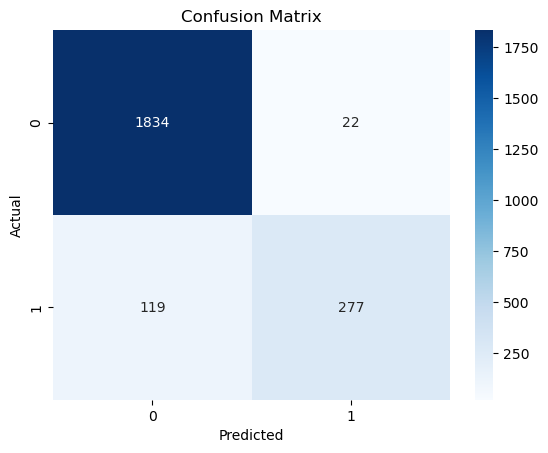

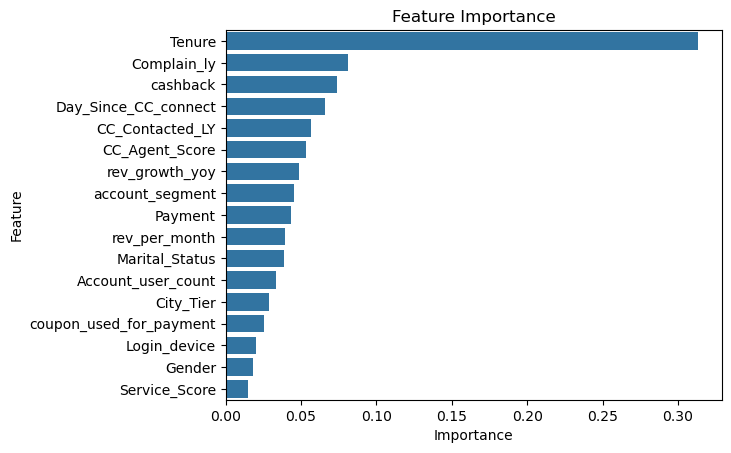

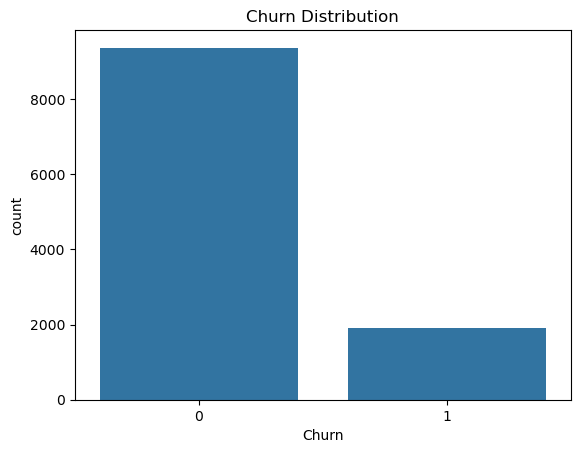

In [1]:
import pandas as pd
df = pd.read_excel(r"C:\Users\ammus\Downloads\loyalityvision\loyallity_vision_analytics.xlsx")
df.head()
# ==============================
# Data Cleaning
# ==============================
df = df.drop(columns=['AccountID'])
df.fillna(df.median(numeric_only=True), inplace=True)

# ==============================
# Encode Categorical Variables
# ==============================
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))

# ==============================
# Train-Test Split
# ==============================
from sklearn.model_selection import train_test_split

X = df.drop(columns='Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# Model Training
# ==============================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# Model Evaluation
# ==============================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# Confusion Matrix (IMPORTANT)
# ==============================
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# Feature Importance (HIGH MARKS)
# ==============================
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

# ==============================
# Churn Distribution
# ==============================
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()